In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

In [3]:
img_size = 180
batch_size = 32

In [4]:
data_train_path = 'data_split/train'
data_test_path = 'data_split/test'

In [34]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

Found 1133 files belonging to 24 classes.
Using 907 files for training.
Found 1133 files belonging to 24 classes.
Using 226 files for validation.


In [35]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [36]:
def preprocess(image, label):
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label

train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)

In [37]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(img_size, img_size, 3)
)

base_model.trainable = False  # Freeze base

In [38]:
from tensorflow.keras import layers

model = tf.keras.Sequential([
    layers.Input(shape=(img_size, img_size, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

In [39]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [40]:
# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=
# )
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 367ms/step - accuracy: 0.0463 - loss: 4.1666 - val_accuracy: 0.0619 - val_loss: 3.1204
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 289ms/step - accuracy: 0.0650 - loss: 3.7821 - val_accuracy: 0.1283 - val_loss: 3.0102
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 294ms/step - accuracy: 0.0871 - loss: 3.5149 - val_accuracy: 0.1770 - val_loss: 2.8971
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 297ms/step - accuracy: 0.1345 - loss: 3.2162 - val_accuracy: 0.2257 - val_loss: 2.7850
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 309ms/step - accuracy: 0.1797 - loss: 2.9470 - val_accuracy: 0.2655 - val_loss: 2.6704
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 317ms/step - accuracy: 0.2326 - loss: 2.7597 - val_accuracy: 0.2876 - val_loss: 2.5608
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 324ms/step - accuracy: 0.2470 - loss: 2.6297 - val_accuracy: 0.3319 - val_loss: 2.4525
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 322ms/step - accuracy: 0.2811 - loss: 2.4836 - val_accuracy: 0

In [45]:
from tensorflow.keras.preprocessing import image

image_path = "test8.jpg"   # <-- change if needed

# Load image
img = image.load_img(image_path, target_size=(img_size, img_size))

# Convert to array
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# IMPORTANT: Apply same preprocessing
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

# Predict
predictions = model.predict(img_array)

# Get predicted class
predicted_class_index = np.argmax(predictions)
confidence = np.max(predictions)

print("Predicted Class:", class_names[predicted_class_index])
print("Confidence:", round(float(confidence)*100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Predicted Class: Melasma
Confidence: 25.49 %


In [28]:
# base_model.trainable = True

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# history_fine = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=5
# )

base_model.trainable = True

for layer in base_model.layers[:-10]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 369ms/step - accuracy: 0.3991 - loss: 1.9354 - val_accuracy: 0.3982 - val_loss: 1.9967
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 315ms/step - accuracy: 0.3859 - loss: 1.9525 - val_accuracy: 0.3938 - val_loss: 1.9987
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 313ms/step - accuracy: 0.4057 - loss: 1.9094 - val_accuracy: 0.3982 - val_loss: 2.0004
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 313ms/step - accuracy: 0.4388 - loss: 1.8758 - val_accuracy: 0.3982 - val_loss: 2.0009
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 336ms/step - accuracy: 0.4355 - loss: 1.8511 - val_accuracy: 0.3982 - val_loss: 2.0016


Text(0.5, 1.0, 'Loss')

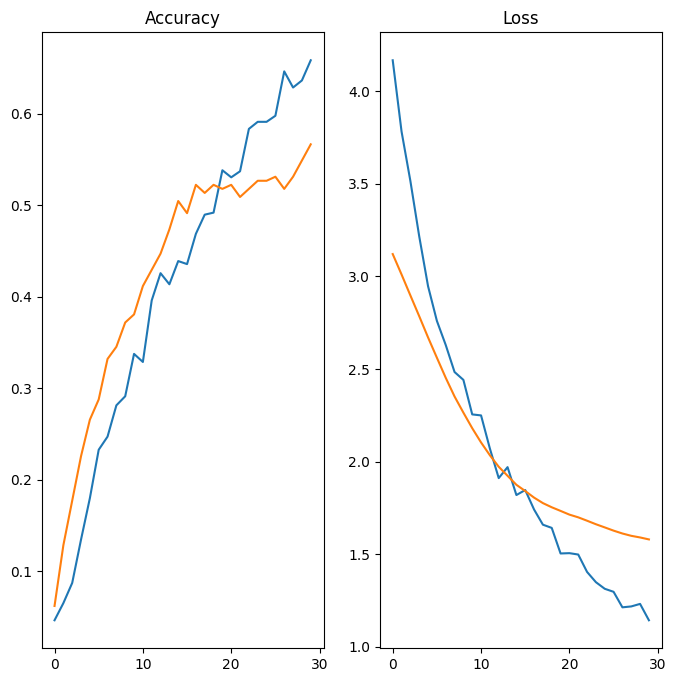

In [42]:
epochs_range = range(30)
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(epochs_range,history.history['accuracy'],label = 'Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'],label = 'Validation Accuracy')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,history.history['loss'],label = 'Training Loss')
plt.plot(epochs_range, history.history['val_loss'],label = 'Validation Loss')
plt.title('Loss')

In [43]:
image_path = "test6.jpg"   # <-- change if needed

# Load image
img = image.load_img(image_path, target_size=(img_size, img_size))

# Convert to array
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# IMPORTANT: Apply same preprocessing
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

# Predict
predictions = model.predict(img_array)

# Get predicted class
predicted_class_index = np.argmax(predictions)
confidence = np.max(predictions)

print("Predicted Class:", class_names[predicted_class_index])
print("Confidence:", round(float(confidence)*100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
Predicted Class: Erythrasma
Confidence: 70.58 %


In [44]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 797ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 819ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 828ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 836ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 815ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 852ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
                    precision    recall  f1-score   support

              Acne       0.43      0.55      0.48        11
 Actinic Keratosis       0.46      0.43      0.44        14
     Chromhidrosis       0.33      0.44      0.38         9
Eruptive Xanthomas       0.80      0.50      0.62         8
        Erythrasma       1.00      0.50      0.67         4
          Impetigo       0.33      0.14      0.20         7
 Keratosis Pilaris       0.63      0.80      0.71        15
           Leprosy       0.62      0.62      0.62         8
             Lupus       0.67      0.36      0.47        11
      Lyme Disease       0.56      0.42      0.48        12
           Measles       0.69 

In [47]:
model.save('Image_classify_v4.keras')

In [46]:
import tensorflow as tf
model = tf.keras.models.load_model("Image_classify_v4.keras")

ValueError: File not found: filepath=Image_classify_v4.keras. Please ensure the file is an accessible `.keras` zip file.